In [4]:
# manipulacja danymi
import numpy as np
import pandas as pd

# wizualizacja danych
import matplotlib.pyplot as plt
import seaborn as sns

# statystyczna analiza danych
from scipy import stats

# przygotowanie danych
from sklearn.preprocessing import StandardScaler, MinMaxScaler
dataset = pd.read_csv('titanic.csv')
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
age_values = dataset.loc[dataset['Age'].notnull(), 'Age'].values
print(age_values.shape)

(714,)


# HISTOGRAM

Histogram to wizualna reprezentacja uporządkowanych obserwacji. Jest on podobny do wykresu słupkowego, jednak w tym przypadku grupuj posortowane wartości z zakresu osi x. Oś y przedstawia liczbę lub procent wystąpień danych z każdego ‘słupka’. Jest to popularna forma wizualizacji rozkładu danych. Na przykładzie naszych danych możemy określić ilu pasażerów było w wieku 0-10 lat, 11-20 lat, 21-30 lat itd.

Zarówno histogramy, jak i wykresy słupkowe umożliwiają wizualne przedstawienie danych za pomocą kolumn, a ludzie często używają tych terminów zamiennie. Bardziej technicznie rzecz biorąc, histogram przedstawia rozkład częstości występowania zmiennych w zbiorze danych. Z drugiej strony, wykres słupkowy zwykle przedstawia graficzne porównanie zmiennych kategorycznych. Wykorzystując histogram funkcją hist z biblioteki matplotlib domyślnie ustawiono 10 ‘pudełek’. Stwórzmy zatem histogram dla zmiennej wiek, ustawmy jednak 20 ‘pudełek’.

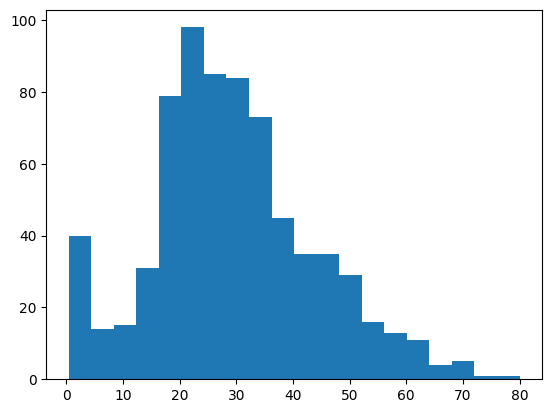

In [6]:
plt.hist(age_values, bins=20)
plt.show()

Więcej było noworodków/małych dzieci niż nastolatków oraz najczęstszy wiek pasażera to ten z zakresu 20-35.

# ŚREDNIA

Średnia jest równa sumie wszystkich wartości w zbiorze danych podzielonej przez liczbę wartości w zbiorze danych.

In [8]:
mean_age = np.round(np.mean(age_values))
print(mean_age)

30.0


Średni wiek pasażera to 30 lat. Nanieśmy tę wartość na histogram.

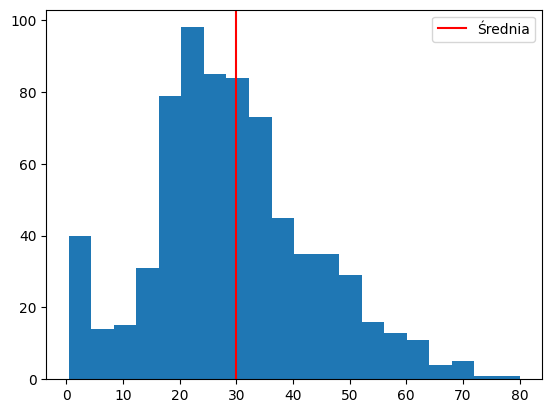

In [9]:
plt.hist(age_values, bins=20)
plt.axvline(x = mean_age, color='red', label = 'Średnia')
plt.legend(loc='upper right')
plt.show()

BINS W funkcji plt.hist() parametr bins=20 określa, na ile przedziałów („koszyków”, słupków histogramu) mają zostać podzielone dane.

    Przykład:

Jeśli wiek w danych jest od 0 do 80 lat, to przy:

bins=20
podziel zakres wartości age_values na 20 przedziałów i policz, ile obserwacji wpada do każdego z nich.

Histogram pokazuje więc rozkład danych.

czyli przedziały np.:

0–4
4–8
8–12
itd.

# MEDIANA

Jest to środkowa liczba na posortowanej liście wartości. Medianę stosuje się w celu odróżnienia od średniej, gdy dla danej cechy występują wartości odstające. W przypadku nieparzystej liczby wartości medianą jest wartość, która znajduje się pośrodku, z taką samą liczbą liczb przed i po niej. Jeśli w liście jest parzysta liczba wartości, należy wyznaczyć środkową parę, dodać ją do siebie i podzielić przez dwa, aby znaleźć wartość mediany.

In [10]:
median_age = np.median(age_values)
print(median_age)

28.0


Jak widzimy mediana jest przesunięta trochę w lewo względem średniej.

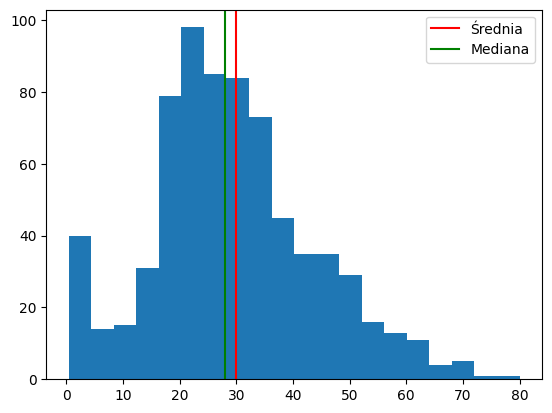

In [12]:
plt.hist(age_values, bins=20)
plt.axvline(x = mean_age, color='red', label = 'Średnia')
plt.axvline(x = median_age, color='green', label = 'Mediana')
plt.legend(loc='upper right')
plt.show()

Mediana jest odporna na wartości odstające, ponieważ jest wyliczana na podstawie wartości środkowych w rozkładzie i odrzuca te minimalne oraz maksymalne wartości. Nie można tego powiedzieć o średniej arytmetycznej, ponieważ jest brana cała próba do jej obliczenia, przez co jest wrażliwa na wartości odstające. Wartościami odstającymi nazywamy te, które są dużo mniejsze lub dużo większe w stosunku do większości wartości. Warto o tym pamiętać, aby nie wyciągnąć błędnych wniosków.

# MODA

Jest to wartość lub wartości, które występują najczęściej w zbiorze danych. Do tego wykorzystamy moduł stats z biblioteki scipy.

In [13]:
mode_age = stats.mode(age_values)
print(mode_age)

ModeResult(mode=np.float64(24.0), count=np.int64(30))



Najwięcej pasażerów w naszej próbie było w wieku 24 lat i było 30 takich osób.

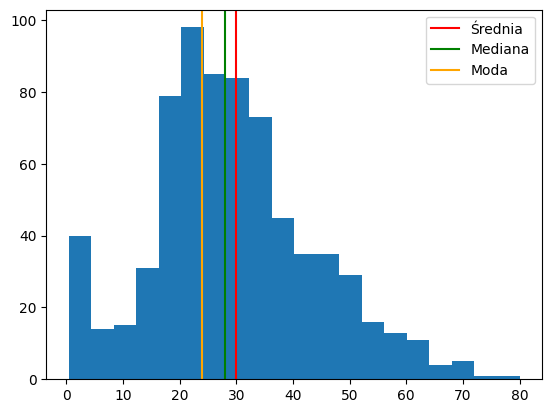

In [14]:
plt.hist(age_values, bins=20)
plt.axvline(x = mean_age, color='red', label = 'Średnia')
plt.axvline(x = median_age, color='green', label = 'Mediana')
plt.axvline(x = mode_age[0], color='orange', label = 'Moda')
plt.legend(loc='upper right')
plt.show()

# Kwartyle

Kwartyle to podzielenie obserwacji na cztery przedziały. Możesz sobie to wyobrazić jako trzy linie, które dzielą zbiór obserwacji na cztery podzbiory:

Pierwszy kwartyl (Q1) – taka wartość dla których 25% obserwacji jest mniejszych, zaś 75% obserwacji jest większych.
Drugi kwartyl (Q2) – jest o mediana, która dzieli obserwacje na dwie części.
Trzeci kwartyl (Q3) – 75% obserwacji mniejszych, a 25% obserwacji jest większych.
Q0 oraz Q4 odpowiadają minimalnej i maksymalnej wartości.

Policzmy zatem kwartyle dla zmiennej wiek, Q2 jest równy medianie :)

In [15]:
q0 = np.quantile(age_values, 0.0)
q1 = np.round(np.quantile(age_values, 0.25))
q3 = np.round(np.quantile(age_values, 0.75))
q4 = np.round(np.quantile(age_values, 1.0))
print(f'Q0: {q0}')
print(f'Q1: {q1}')
print(f'Q2: {median_age}')
print(f'Q3: {q3}')
print(f'Q4: {q4}')

Q0: 0.42
Q1: 20.0
Q2: 28.0
Q3: 38.0
Q4: 80.0


Czas na podstawie tego wyciągnąć wnioski. Najmłodsza osoba to noworodek i nawet nie miał pół roku, najstarsza osoba to osiemdziesięciolatek. 75% osób miało nie więcej niż 38 lat, zatem wartość maksymalna jest ponad dwukrotnie większa niż trzeci kwartyl. Już tu widzimy, że nasz rozkład jest skośny, o czym będzie jeszcze więcej niedługo. Dodajmy do wizualizacji kwartyle.

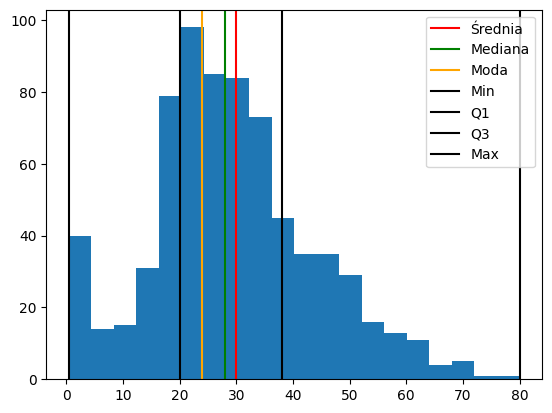

In [16]:
plt.hist(age_values, bins=20)
plt.axvline(x = mean_age, color='red', label = 'Średnia')
plt.axvline(x = median_age, color='green', label = 'Mediana')
plt.axvline(x = mode_age[0], color='orange', label = 'Moda')
plt.axvline(x = q0, color='black', label = 'Min')
plt.axvline(x = q1, color='black', label = 'Q1')
plt.axvline(x = q3, color='black', label = 'Q3')
plt.axvline(x = q4, color='black', label = 'Max')
plt.legend(loc='upper right')
plt.show()

Warto zapamiętać ten kod, zapewne przyda Ci się w Twoich późniejszych projektach.

Warto znać również pojęcie decyli (dzieli posortowany zbiór na 10 części) oraz percentyle (dzieli posortowany zbiór na 100 części).

# ZAKRES

Miary tendencji centralnej, które służą do podsumowania zmiennej. Przejdźmy teraz do metryk związanych z rozproszeniem, czyli zmiennością rozkładu. Zakres to pierwsza taka miara i jest to rozpiętość danych od najniższej do najwyższej wartości w rozkładzie. Tę miarę oblicza się odejmując najniższą wartość od wartości najwyższej. Duży przedział oznacza dużą zmienność, a mały przedział małą zmienność rozkładu.

In [19]:
range_age = max(age_values) - min(age_values)
print(range_age)

79.58


W zbiorze danych zakres danych to prawie 80 lat!

# Rozstęp międzykwartylowy - IQR

Kwartyle dzielą każdy rozkład, który jest uporządkowany od najniższego do najwyższego, na cztery równe części. Rozstęp międzykwartylowy IQR (InterQuartile Range) zawiera pierwszy i trzeci kwartyl, czyli jest to środkowa połowa rozkładu zmiennej. Jest to zatem różnica pomiędzy Q3 oraz Q1.

image
Jest to zakres pomiędzy percentylem 25 a percentylem 75 i ta miara jest lepszą oraz szerzej stosowaną miarą, ponieważ mierzy rozproszenie środkowej części danych i jest mniej wrażliwa na wartości odstające.

In [20]:
iqr = q3 - q1
print(iqr)

18.0


Dla przypomnienia Q1 to 20 lat, zaś Q3 to 38 lat, w związku z tym 50% osób jest w zakresie tego wieku. Na podstawie kwartyli oraz metryki IQR powstał wykres pudełkowy – BoxPlot.


Wykres pudełkowy jest rysowany jako pudełko, które rozciąga się od wartości Q1 do Q3. Wewnątrz pudełka jest linia określająca wartość mediany. Linie rozciągające się od pudełek nazywane są wąsami (whiskers), których celem jest wskazanie zmienności poza dolnym i górnym kwartylem. Ich długość jest do półtorej wartości rozstępu międzykwartylowego – IQR. Jeśli wartość minimalna lub maksymalna jest bliżej, to wtedy też wąs jest krótszy. Jeśli istnieją wartości poza wąsem, to wąs jest równy jako 1.5 IQR, a poza wąsem znajdują się punkty, które mogą być uznane jako wartości odstające.

Stwórzmy wykres pudełkowy dla zmiennej wieku.

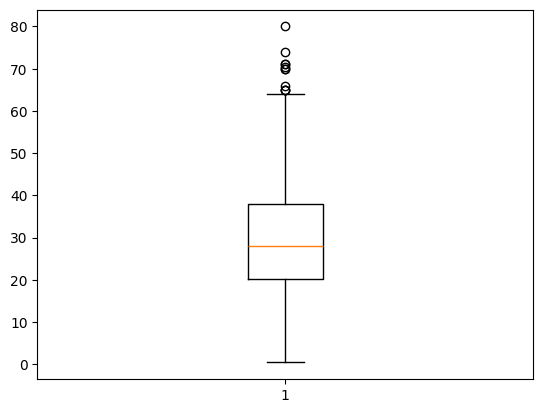

In [21]:
plt.boxplot(age_values)
plt.show()

Jak widzisz są wartości odstające dla osób starszych, świadczy to o tym, że w tym miejscu rozkładu wartości są rzadkie, jest ich niewiele.

# Wariancja

Wariancja to miara rozpiętości między liczbami w zbiorze danych. Mówiąc dokładniej, wariancja mierzy, jak bardzo każda liczba w zbiorze jest oddalona od średniej, a tym samym od każdej innej liczby w zbiorze.

Oblicza się ją, biorąc różnice między każdą liczbą w zbiorze danych a średnią, następnie podnosząc te różnice do kwadratu, aby były dodatnie, a na koniec dzieląc sumę kwadratów przez o jedną mniejszą liczbę wartości w zbiorze danych. Duża wariancja wskazuje, że liczby w zbiorze są dalekie od średniej i dalekie od siebie nawzajem. Z kolei mała wariancja wskazuje, że jest odwrotnie. Wariancja równa zero oznacza, że wszystkie wartości w zbiorze liczb są identyczne. Każda wariancja, która nie jest równa zero, jest liczbą dodatnią. Wariancja nie może być ujemna. Jest to matematycznie niemożliwe, ponieważ nie można uzyskać ujemnej wartości będącej wynikiem kwadratu.

Dlaczego w mianowniku jest n-1 a nie samo n?

W przypadku pracy nad próbą danych we wzorze używamy n - 1, ponieważ użycie n dałoby nam nieobiektywne oszacowanie, które konsekwentnie zaniżałoby zmienność. Wariancja z próby byłaby zwykle niższa niż rzeczywista wariancja populacji.

Zmniejszenie próby n do n - 1 powoduje, że wariancja jest sztucznie zwiększona, co daje nieobiektywne oszacowanie zmienności: lepiej jest przeszacować niż niedoszacować zmienność w próbach. Ma to związek ze stopniami swobody. Jeśli będzie coraz większa liczba n, to różnica dla wariancji z n-1 a n będzie coraz mniejsza.

Aby obliczyć wariancję korzystamy z biblioteki Numpy i funkcji var. W celu policzenia wariancji dla próby ustawiamy parametr ddof na wartość 1.

In [22]:
variance_age = np.var(age_values, ddof=1)
print(variance_age)

211.01912474630805


# Odchylenie standardowe

Wariancja jest trudna do oceny, ponieważ nie jest w takich wartościach, jak badana zmienna. Czy wariancja 200 to dużo? Dlatego stosuje się odchylenie standardowe, które jest pierwiastkiem z wariancji.

Im bardziej punkty danych są oddalone od średniej, tym większe jest odchylenie w zbiorze danych. Dlatego im bardziej dane są rozproszone, tym wyższe jest odchylenie standardowe.

Możemy obliczyć to jako pierwiastek poprzedniego działania.

In [23]:
print(variance_age**(1/2))

14.526497332334042


Możemy też skorzystać z funkcji std dostępnej w Numpy.

In [24]:
standard_deviation_age = np.std(age_values, ddof=1)
print(standard_deviation_age)

14.526497332334042


# ASYMETRIA ROZKLADU

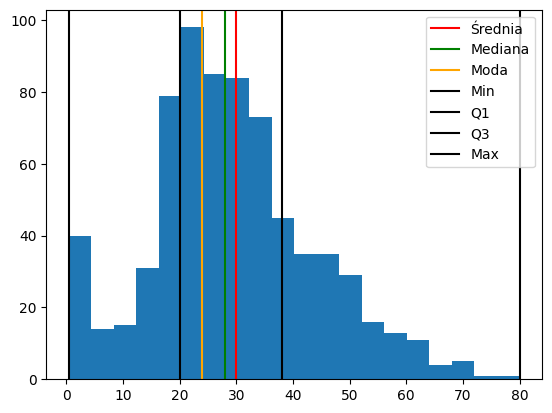

In [27]:
plt.hist(age_values, bins=20)
plt.axvline(x = mean_age, color='red', label = 'Średnia')
plt.axvline(x = median_age, color='green', label = 'Mediana')
plt.axvline(x = mode_age[0], color='orange', label = 'Moda')
plt.axvline(x = q0, color='black', label = 'Min')
plt.axvline(x = q1, color='black', label = 'Q1')
plt.axvline(x = q3, color='black', label = 'Q3')
plt.axvline(x = q4, color='black', label = 'Max')
plt.legend(loc='upper right')
plt.show()

Rozkład zmiennej 'wiek' wydaje się być pozytywnie skośnym, ponieważ najpierw widzimy modę, następnie w prawo jest mediana, a jeszcze dalej w prawo jest średnia. Gdyby był to rozkład normalny, to te metryki byłyby sobie równe. Poniżej zobacz możliwe rozkłady asymetryczne i symetryczny rozkład normalny.

Nie musimy jednak patrzeć na rozkład, aby zdecydować o tym, wystarczy policzyć współczynnik asymetrii. W przypadku danych o rozkładzie normalnym skośność powinna wynosić około zera. W przypadku rozkładów skośnych dodatnio wartość współczynnika jest większa od 0, w przypadku rozkładów skośnych ujemnie wartość współczynnika jest mniejsza od 0.

Z rozkładamy symetrycznymi prawie nigdy nie mamy do czynienia – taki jest świat. Jednak im bliższe rozkłady są symetrycznym, tym lepiej będą działały modele parametryczne uczenia maszynowego, które poznasz w późniejszych modułach. Warto o tym pamiętać.

# SKALOWALSNOSC ZMIENNEJ

Najpierw odpowiedzmy dlaczego istotne jest, aby skalować zmienne. To również odnosi się do modeli parametrycznych (jak na przykład regresja liniowa), gdy korzystamy z tego typu modeli ważne jest, aby wszystkie zmienne były w tej samej skali. Niektóre modele są bardzo wrażliwe na cechy w różnej skali, a niektóre nie – trzeba to wiedzieć i dla tych modeli wrażliwych na skale należy skalować. Sprawdźmy teraz metody, jak to możemy zrobić.

# Standaryzacja to technika skalowania, w której wartości są wyśrodkowane wobec średniej i wyskalowane wobec średniej. Tak skalowane dane mają średnią równą 0 oraz odchylenie standardowe równe 1. Od każdej wartości odejmujemy średnią i następnie dzielimy przez odchylenie standardowe.

Teraz czas to wdrożyć w Pythonie i sprawdzić rozkład danych. Do tego skorzystamy z StandardScaler, który jest dostępny w Scikit-learn.

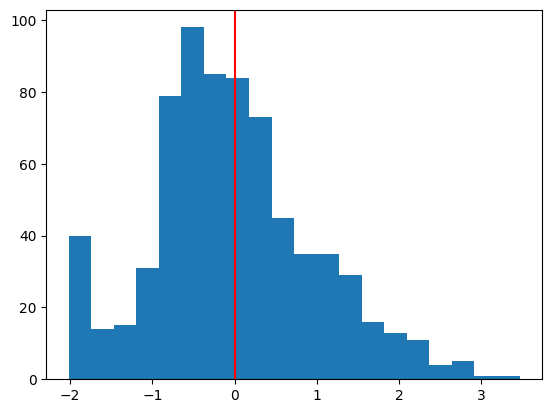

Średnia: 2.338621049070358e-16
Odchylenie standardowe: 1.000701016559981


In [28]:
scaler_standardized = StandardScaler()
standardized_age_values = scaler_standardized.fit_transform(age_values.reshape(-1, 1))
plt.hist(standardized_age_values, bins=20)
plt.axvline(x = standardized_age_values.mean(), color='red', label = 'Średnia')
plt.show()
print(f'Średnia: {standardized_age_values.mean()}')
print(f'Odchylenie standardowe: {np.std(standardized_age_values, ddof=1)}')


Zobacz, średnia nie jest równa 2, tylko 2 do 10-16. Zastosowaliśmy metodę fit_transform. Odnieśmy się do tego czego będziesz uczyć się w następnych modułach. Tak samo musisz działać na zbiorze treningowym, natomiast na zbiorze testowym wykonać jedynie metodę transform, wtedy zbiór zostanie przekształcony w oparciu o średnią i odchylenie standardowe ze zbioru treningowego. W tym przypadku obliczyliśmy inaczej średnią, odwołaliśmy się do metody mean, która jest dostępna dla obiektów numpy array.

# Min Max Scaler to kolejna technika do skalowania, w której wartości są przesuwane i przeskalowywane w taki sposób, aby ostatecznie znalazły się w przedziale od 0 do 1

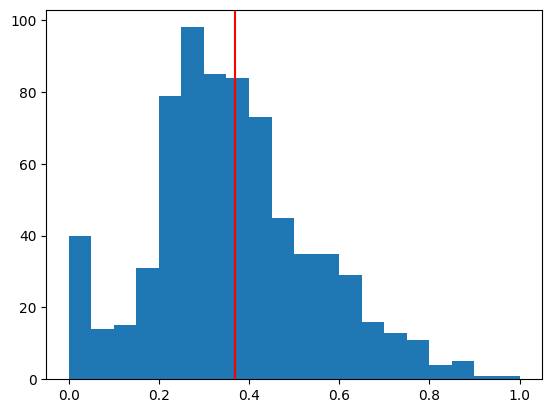

Średnia: 0.3679205534940792
Odchylenie standardowe: 0.1825395492879372


In [29]:
scaler_MinMax = MinMaxScaler()
normalized_age_values = scaler_MinMax.fit_transform(age_values.reshape(-1, 1))
plt.hist(normalized_age_values, bins=20)
plt.axvline(x = normalized_age_values.mean(), color='red', label = 'Średnia')
plt.show()
print(f'Średnia: {normalized_age_values.mean()}')
print(f'Odchylenie standardowe: {np.std(normalized_age_values, ddof=1)}')

Która technika jest lepsza? Niestety odpowiedź jest jedna – ‘to zależy’. Dlatego warto sprawdzić obie i wybrać taką, która daje lepsze wyniki w konkretnej sytuacji.

# Korelacja

o tej pory obliczaliśmy metryki dla jednej zmiennej, jednak czasem chcielibyśmy sprawdzić czy istnieje związek pomiędzy zmiennymi losowymi. Mamy wiek pasażera i sprawdźmy, jak ma się on do zmiennej SibSp (czyli liczby, która jest sumą rodzeństwa czy małżonka na pokładzie). Zanim będziemy cokolwiek wyliczać, najpierw zwizualizujmy to, wykorzystując wykres punktowy, gdzie na osi x będzie wiek, a na osi y zmienna SibSp. Weźmiemy jedynie te obserwacje, dla których są też obserwacje dla wieku, zatem obserwacji, gdzie brakuje wartości dla wieku nie weźmiemy pod uwagę.

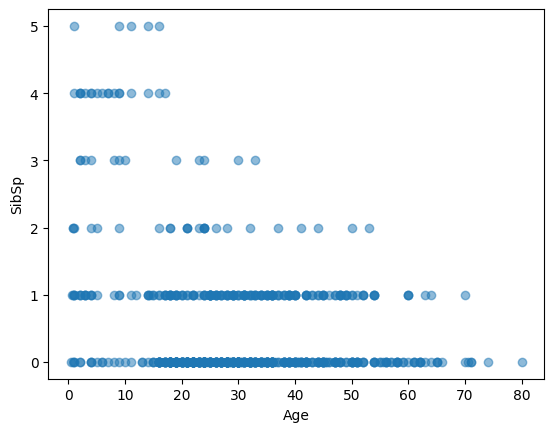

In [30]:
sibsb_values = dataset.loc[dataset['Age'].notnull(), 'SibSp'].values
plt.scatter(x=age_values, y=sibsb_values, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('SibSp')
plt.show()

Pomiędzy zmiennymi mamy taki związek, że im starsza osoba na pokładzie tym mniej osób, które byłyby rodzeństwem tej osoby bądź małżonkiem. Dlaczego tak jest? Chyba nie trzeba być specjalistą z socjologii, by to wydedukować. Małe dzieci czy nastolatkowie jeżdżą całą rodziną na wakacje, w tym z rodzeństwem, o ile takie mają. Im jesteś starszy to raczej nie jeździsz z całym rodzeństwem, a jedynie ze swoim małżonkiem. Kolejny powód jest brutalny, jednak prawdziwy – im jesteś starszy tym większe prawdopodobieństwo, że Twoje rodzeństwo czy współmałżonek już nie żyją. Widzimy taki związek pomiędzy zmiennymi losowymi, zatem chcielibyśmy obliczyć metrykę, która pokaże nam, jak silny jest to związek. Do tego wyliczymy najpopularniejszy współczynnik korelacji – korelację Pearsona.



Jest to miara korelacji LINIOWEJ (o czym zaraz się przekonasz) pomiędzy dwoma zmiennymi. Jest to znormalizowana miara kowariancji, tak że wynik zawsze ma wartość z przedziału od -1 do 1. Podobnie jak sama kowariancja, miara ta może odzwierciedlać jedynie liniową korelację zmiennych i ignoruje wiele innych rodzajów związków lub korelacji. Na prostym przykładzie można by oczekiwać, że wiek i wzrost badanych nastolatków ze szkoły średniej będą miały współczynnik korelacji Pearsona znacznie większy od 0, ale mniejszy od 1 (ponieważ 1 oznaczałoby nierealistycznie doskonałą korelację). W związku z tym mamy korelację dodatnią (obie zmienne wzrastają) lub ujemną (taka jak dla naszego przykładu – wiek wzrasta i maleje liczba rodzeństwa i małżonka na pokładzie). Policzmy korelacje Pearsona dla tych zmiennych.

In [31]:
stats.pearsonr(age_values, sibsb_values)

PearsonRResult(statistic=np.float64(-0.30824675892365666), pvalue=np.float64(3.5090251937846174e-17))

Na wyjściu otrzymujemy krotkę. Pierwszą wartością jest współczynnik korelacji, który wynosi -0.3. Zatem tak, jak pisaliśmy wyżej – korelacja dla tych zmiennych jest ujemna. Wartość p jest używana w metodach statystycznych podczas testowania hipotezy. Wartość p jest ważną miarą, której interpretacja wymaga dogłębnej znajomości rachunku prawdopodobieństwa i statystyki. W tym przypadku p value jest bardzo niskie, zatem możemy odrzucić hipotezę o losowości i uznać, że ta korelacja to nie przypadek.

Korelacja Pearsona oblicza jedynie poziom zależności liniowej pomiędzy zmiennymi losowymi. Sprawdź poniższą grafikę, na której są różne korelacje, jednak korelacja Pearsona nie potrafi ich wychwycić.

Korelacja jednak nie jest tym samym co zależność, korelacja nie oznacza przyczynowości. Wejdź na tę stronę, gdzie pokazano ciekawe przykłady. Możesz sobie pomyśleć, jest korelacja, to też jest zależność – nie jest to jednak słuszne założenie. Zerknij na przykład na liczbę osób, które utonęły wpadając do basenu w danym roku oraz liczbę filmów, w których wystąpił Nicolas Cage w danym roku.

In [32]:
# https://www.tylervigen.com/spurious-correlations

Korelacja to aż 66.6%, ale czy to oznacza, że powinniśmy zakazać aktorowi występować w filmach? Czy to spowoduje, że ludzie przestaną tonąć w basenach? Nie możesz wyciągać wniosku o związku przyczynowo-skutkowym między dwoma zdarzeniami lub zmiennymi wyłącznie na podstawie zaobserwowanego związku lub korelacji między nimi. Koncepcja, że "korelacja implikuje związek przyczynowy", jest przykładem logicznego błędu zapytania o przyczynę, w którym dwa zdarzenia występujące razem uznaje się za ustanawiające związek przyczynowo-skutkowy.